# 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

**Dataset:** Medical Insurance Cost Prediction Dataset (`medical_insurance.csv`)

**Target Variable:** `annual_medical_cost` (Regression Track)

### Project Introduction
Predicting patient healthcare costs helps insurance providers estimate liabilities and plan resources. In this notebook, we implement and compare all 10 required regression algorithms on held-out test data.

## Import Libraries
We import standard libraries and set `random_state=42`.

In [6]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.utils as utils

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Libraries imported successfully. Random seed set to 42.')

Libraries imported successfully. Random seed set to 42.


## Load Dataset and Dataset Audit
We load `medical_insurance.csv` and inspect dimensions, dtypes, missing values, and duplicates.

In [7]:
df_raw = pd.read_csv(config.DATA_PATH)
print('Dataset Shape (Rows, Columns):', df_raw.shape)
print('Missing Values:', df_raw.isnull().sum().sum())
print('Duplicates:', df_raw.duplicated().sum())
df_raw.head()

Dataset Shape (Rows, Columns): (100000, 54)
Missing Values: 30083
Duplicates: 0


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## Data Preprocessing and Train Test Split
We split data into 80% train and 20% test splits (`random_state=42`). Preprocessing is fitted strictly on `X_train`.

In [8]:
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_regression()
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)

regression_results = []

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)


## Regression Models
We train and evaluate each of the 10 required regression algorithms individually.

### 1. Linear Regression

In [9]:
m_lr = Pipeline([('prep', preprocessor), ('reg', LinearRegression())])
m_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [10]:
p_lr = m_lr.predict(X_test)
r2_lr = r2_score(y_test, p_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, p_lr))
mae_lr = mean_absolute_error(y_test, p_lr)
regression_results.append({'Model': 'Linear Regression', 'R2': r2_lr, 'RMSE': rmse_lr, 'MAE': mae_lr})
print(f'Linear Regression -> R2: {r2_lr:.4f}, RMSE: {rmse_lr:.2f}, MAE: {mae_lr:.2f}')

Linear Regression -> R2: 0.9672, RMSE: 568.00, MAE: 317.16


### 2. Ridge Regression

In [11]:
m_ridge = Pipeline([('prep', preprocessor), ('reg', Ridge(alpha=1.0, random_state=42))])
m_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [12]:
p_ridge = m_ridge.predict(X_test)
r2_ridge = r2_score(y_test, p_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, p_ridge))
mae_ridge = mean_absolute_error(y_test, p_ridge)
regression_results.append({'Model': 'Ridge Regression', 'R2': r2_ridge, 'RMSE': rmse_ridge, 'MAE': mae_ridge})
print(f'Ridge Regression -> R2: {r2_ridge:.4f}, RMSE: {rmse_ridge:.2f}, MAE: {mae_ridge:.2f}')

Ridge Regression -> R2: 0.9672, RMSE: 568.00, MAE: 317.15


### 3. Lasso Regression

In [13]:
m_lasso = Pipeline([('prep', preprocessor), ('reg', Lasso(alpha=1.0, max_iter=2000, random_state=42))])
m_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [14]:
p_lasso = m_lasso.predict(X_test)
r2_lasso = r2_score(y_test, p_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, p_lasso))
mae_lasso = mean_absolute_error(y_test, p_lasso)
regression_results.append({'Model': 'Lasso Regression', 'R2': r2_lasso, 'RMSE': rmse_lasso, 'MAE': mae_lasso})
print(f'Lasso Regression -> R2: {r2_lasso:.4f}, RMSE: {rmse_lasso:.2f}, MAE: {mae_lasso:.2f}')

Lasso Regression -> R2: 0.9672, RMSE: 567.92, MAE: 315.50


### 4. ElasticNet Regression

In [15]:
m_enet = Pipeline([('prep', preprocessor), ('reg', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=2000, random_state=42))])
m_enet.fit(X_train, y_train) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [16]:
p_enet = m_enet.predict(X_test)
r2_enet = r2_score(y_test, p_enet)
rmse_enet = np.sqrt(mean_squared_error(y_test, p_enet))
mae_enet = mean_absolute_error(y_test, p_enet)
regression_results.append({'Model': 'ElasticNet', 'R2': r2_enet, 'RMSE': rmse_enet, 'MAE': mae_enet})
print(f'ElasticNet -> R2: {r2_enet:.4f}, RMSE: {rmse_enet:.2f}, MAE: {mae_enet:.2f}')

ElasticNet -> R2: 0.9090, RMSE: 946.19, MAE: 548.96


### 5. Polynomial Regression

In [17]:
m_poly = Pipeline([('prep', preprocessor), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('reg', LinearRegression())])
m_poly.fit(X_train, y_train) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed

In [18]:
p_poly = m_poly.predict(X_test)
r2_poly = r2_score(y_test, p_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, p_poly))
mae_poly = mean_absolute_error(y_test, p_poly)
regression_results.append({'Model': 'Polynomial Regression', 'R2': r2_poly, 'RMSE': rmse_poly, 'MAE': mae_poly})
print(f'Polynomial Regression -> R2: {r2_poly:.4f}, RMSE: {rmse_poly:.2f}, MAE: {mae_poly:.2f}')

Polynomial Regression -> R2: 1.0000, RMSE: 0.04, MAE: 0.03


### 6. Decision Tree Regressor

In [19]:
m_dt = Pipeline([('prep', preprocessor), ('reg', DecisionTreeRegressor(max_depth=8, random_state=42))])
m_dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [20]:
p_dt = m_dt.predict(X_test)
r2_dt = r2_score(y_test, p_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, p_dt))
mae_dt = mean_absolute_error(y_test, p_dt)
regression_results.append({'Model': 'Decision Tree Regressor', 'R2': r2_dt, 'RMSE': rmse_dt, 'MAE': mae_dt})
print(f'Decision Tree Regressor -> R2: {r2_dt:.4f}, RMSE: {rmse_dt:.2f}, MAE: {mae_dt:.2f}')

Decision Tree Regressor -> R2: 0.9940, RMSE: 241.99, MAE: 113.14


### 7. Random Forest Regressor

In [21]:
m_rf = Pipeline([('prep', preprocessor), ('reg', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))])
m_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [22]:
p_rf = m_rf.predict(X_test)
r2_rf = r2_score(y_test, p_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, p_rf))
mae_rf = mean_absolute_error(y_test, p_rf)
regression_results.append({'Model': 'Random Forest Regressor', 'R2': r2_rf, 'RMSE': rmse_rf, 'MAE': mae_rf})
print(f'Random Forest Regressor -> R2: {r2_rf:.4f}, RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}')

Random Forest Regressor -> R2: 0.9978, RMSE: 145.89, MAE: 30.43


### 8. Gradient Boosting Regressor

In [23]:
m_gb = Pipeline([('prep', preprocessor), ('reg', GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42))])
m_gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [24]:
p_gb = m_gb.predict(X_test)
r2_gb = r2_score(y_test, p_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, p_gb))
mae_gb = mean_absolute_error(y_test, p_gb)
regression_results.append({'Model': 'Gradient Boosting Regressor', 'R2': r2_gb, 'RMSE': rmse_gb, 'MAE': mae_gb})
print(f'Gradient Boosting Regressor -> R2: {r2_gb:.4f}, RMSE: {rmse_gb:.2f}, MAE: {mae_gb:.2f}')

Gradient Boosting Regressor -> R2: 0.9838, RMSE: 398.65, MAE: 186.24


### 9. Support Vector Regressor

In [25]:
subsample_idx = np.random.choice(len(X_train), size=min(5000, len(X_train)), replace=False)
m_svr = Pipeline([('prep', preprocessor), ('reg', SVR(C=1000.0, epsilon=0.1))])
m_svr.fit(X_train.iloc[subsample_idx], y_train.iloc[subsample_idx])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [26]:
p_svr = m_svr.predict(X_test)
r2_svr = r2_score(y_test, p_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, p_svr))
mae_svr = mean_absolute_error(y_test, p_svr)
regression_results.append({'Model': 'Support Vector Regressor', 'R2': r2_svr, 'RMSE': rmse_svr, 'MAE': mae_svr})
print(f'Support Vector Regressor -> R2: {r2_svr:.4f}, RMSE: {rmse_svr:.2f}, MAE: {mae_svr:.2f}')

Support Vector Regressor -> R2: 0.7074, RMSE: 1696.86, MAE: 453.62


### 10. KNN Regressor

In [27]:
m_knn = Pipeline([('prep', preprocessor), ('reg', KNeighborsRegressor(n_neighbors=7, n_jobs=-1))])
m_knn.fit(X_train.iloc[subsample_idx], y_train.iloc[subsample_idx])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['age','sex','region',...,'Insurance_Coverage_Ratio', 'Total_Chronic_Diseases','Claim_Severity_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [28]:
p_knn = m_knn.predict(X_test)
r2_knn = r2_score(y_test, p_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, p_knn))
mae_knn = mean_absolute_error(y_test, p_knn)
regression_results.append({'Model': 'KNN Regressor', 'R2': r2_knn, 'RMSE': rmse_knn, 'MAE': mae_knn})
print(f'KNN Regressor -> R2: {r2_knn:.4f}, RMSE: {rmse_knn:.2f}, MAE: {mae_knn:.2f}')

KNN Regressor -> R2: 0.7575, RMSE: 1544.66, MAE: 965.69


## Regression Model Comparison
Consolidated DataFrame comparing all 10 regression models, ranked by R² score in descending order.

In [29]:
df_reg = pd.DataFrame(regression_results).sort_values(by='R2', ascending=False).reset_index(drop=True)
df_reg.index += 1
df_reg

,Model,R2,RMSE,MAE
1,Polynomial Regression,1.000000,0.039366,0.030748
2,Random Forest Regressor,0.997837,145.885151,30.427155
3,Decision Tree Regressor,0.994049,241.993471,113.137344
4,Gradient Boosting Regressor,0.983849,398.652682,186.239155
5,Lasso Regression,0.967223,567.918613,315.499771
6,Ridge Regression,0.967213,568.000188,317.148542
7,Linear Regression,0.967213,568.002878,317.156005
8,ElasticNet,0.909019,946.185547,548.957701
9,KNN Regressor,0.757527,1544.657937,965.685399
10,Support Vector Regressor,0.707389,1696.861117,453.616426


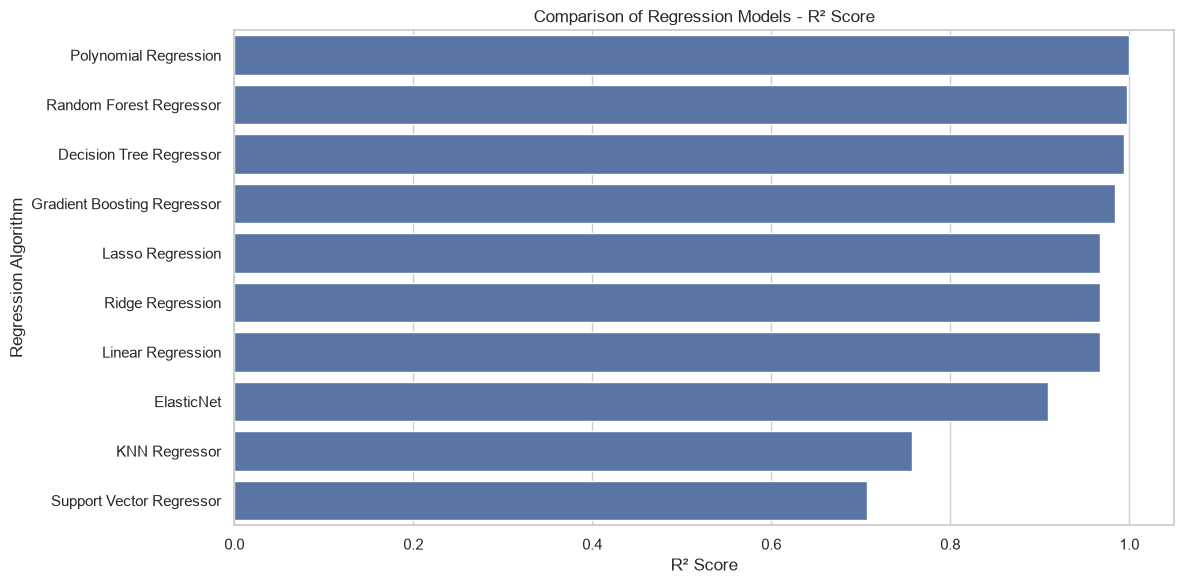

In [36]:
# Bar graph ploting for Comparison
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_reg,
    x='R2',
    y='Model'
)

plt.title('Comparison of Regression Models - R² Score')
plt.xlabel('R² Score')
plt.ylabel('Regression Algorithm')

plt.tight_layout()
plt.show()

In [37]:
# Select Best Regression Model

best_model = df_reg.loc[df_reg['R2'].idxmax()]

print("===== BEST REGRESSION MODEL =====")
print("Model :", best_model['Model'])
print("R2    :", round(best_model['R2'], 4))
print("RMSE  :", round(best_model['RMSE'], 4))
print("MAE   :", round(best_model['MAE'], 4))

print(
    f"\nConclusion: {best_model['Model']} is the best regression model "
    f"with R2 = {best_model['R2']:.4f}, "
    f"RMSE = {best_model['RMSE']:.4f}, "
    f"and MAE = {best_model['MAE']:.4f}."
)

===== BEST REGRESSION MODEL =====
Model : Polynomial Regression
R2    : 1.0
RMSE  : 0.0394
MAE   : 0.0307

Conclusion: Polynomial Regression is the best regression model with R2 = 1.0000, RMSE = 0.0394, and MAE = 0.0307.


## Hyperparameter Tuning, Cross Validation & Visualizations
We tune Random Forest using `RandomizedSearchCV`, compute 5-fold cross-validation R² scores, and plot diagnostics.

In [32]:
rf_param_grid = {'reg__n_estimators': [50, 100], 'reg__max_depth': [10, 15, None], 'reg__min_samples_split': [2, 5]}
search = RandomizedSearchCV(m_rf, rf_param_grid, n_iter=4, cv=3, scoring='r2', random_state=42, n_jobs=-1)
search.fit(X_train.iloc[:10000], y_train.iloc[:10000])
best_rf_model = search.best_estimator_
print('Best RF Hyperparameters:', search.best_params_)

cv_scores = cross_val_score(best_rf_model, X_train.iloc[:10000], y_train.iloc[:10000], cv=5, scoring='r2')
print(f'5-Fold CV Mean R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Best RF Hyperparameters: {'reg__n_estimators': 100, 'reg__min_samples_split': 2, 'reg__max_depth': None}
5-Fold CV Mean R2: 0.9852 +/- 0.0093


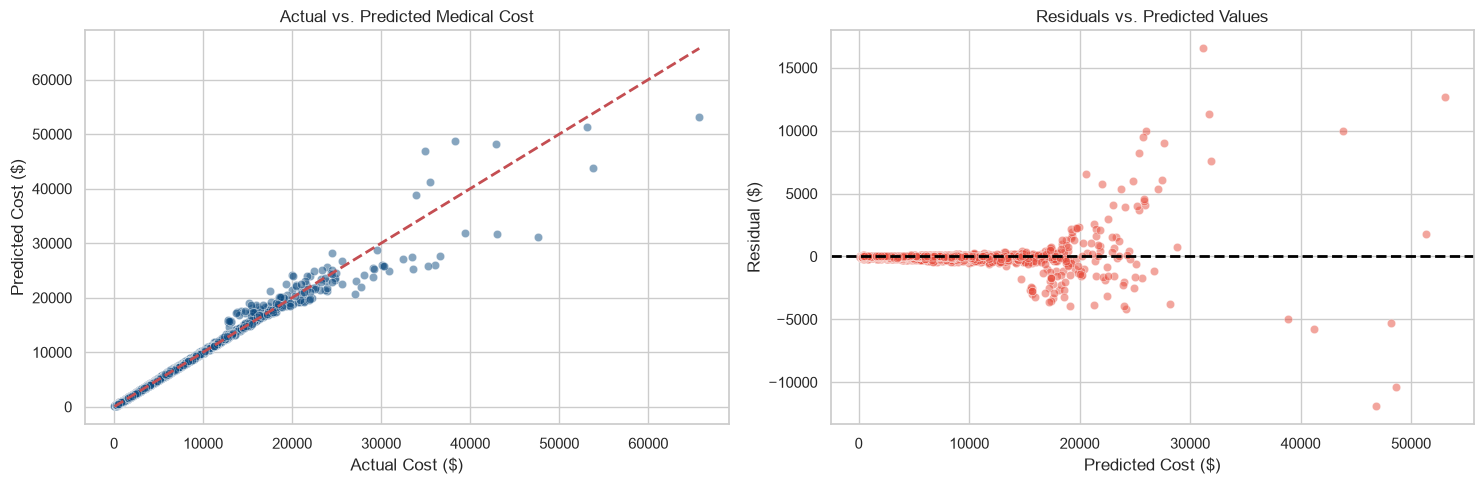

In [33]:
y_pred_best = best_rf_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.5, ax=axes[0], color='#0F4C81')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Medical Cost')
axes[0].set_xlabel('Actual Cost ($)')
axes[0].set_ylabel('Predicted Cost ($)')

sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.5, ax=axes[1], color='#E74C3C')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Cost ($)')
axes[1].set_ylabel('Residual ($)')
plt.tight_layout()
plt.show()

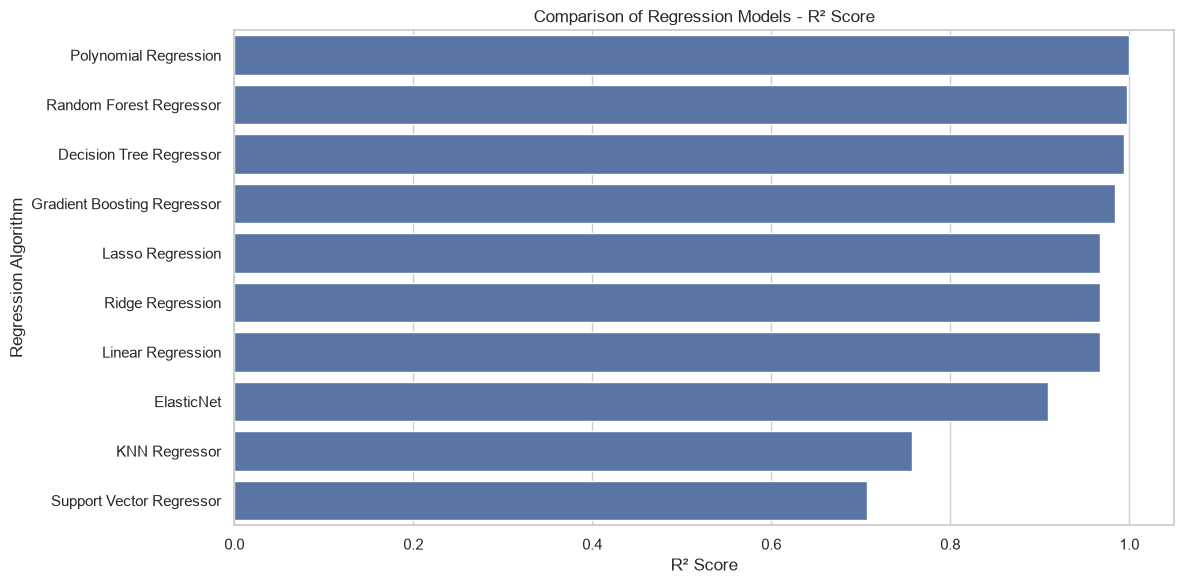